**Final - Random Forest Classifier with Grid Search (Ensemble Model)**

Bu notebook, vize aşamasında temel model (base model) olarak kullanılan KNN ve Extra Trees algoritmalarının ötesine geçmek için Random Forest yönteminin uygulanmasını içermektedir. Kod akışı; veri setinin yüklenmesi ve ön işlenmesi, Grid Search CV yöntemiyle en iyi hiperparametrelerin sistematik olarak belirlenmesi, optimize edilmiş modelin eğitilmesi ve sonuçların karmaşıklık matrisi ile ROC eğrileri üzerinden analiz edilmesi aşamalarından oluşmaktadır.

In [2]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

# Görselleştirme ayarı
sns.set_style("whitegrid")

Veri Seti Boyutu: (13028, 69)


/tmp/ipython-input-4079949275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')


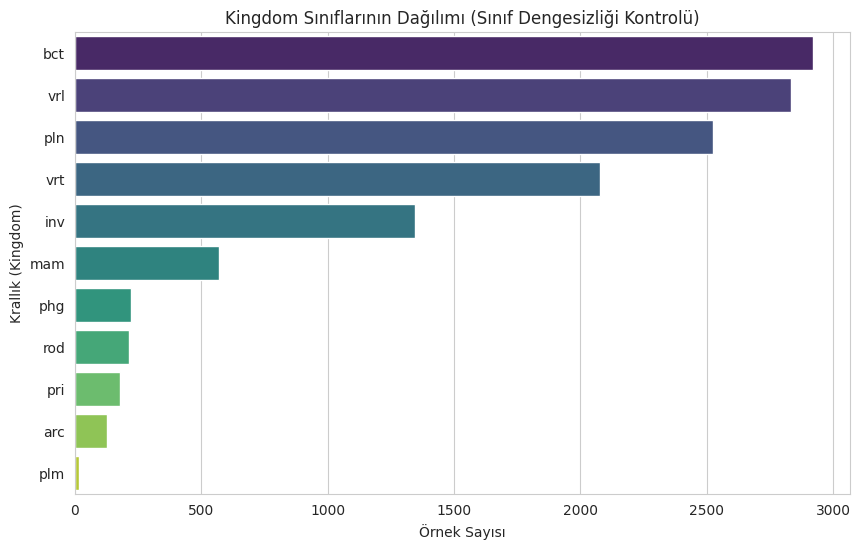

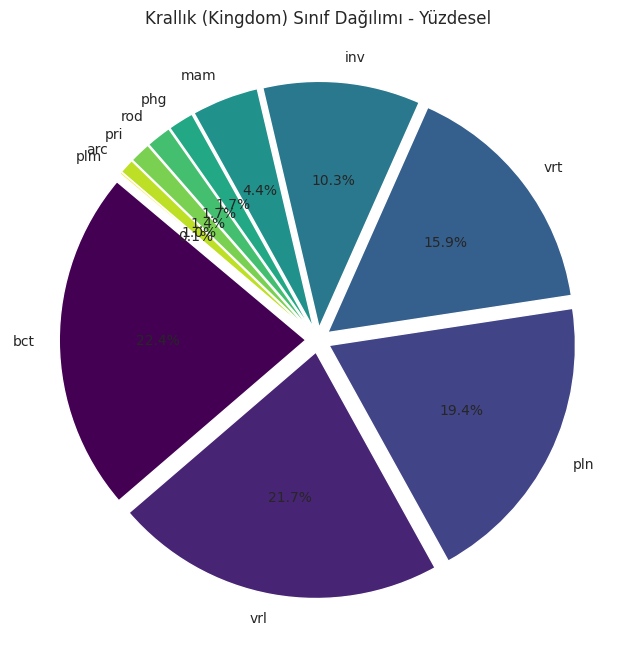

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [3]:
# Veri setinin yüklenmesi
df = pd.read_csv("codon_usage.csv", low_memory=False)

print("Veri Seti Boyutu:", df.shape)

# Kingdom sınıf dağılımının görselleştirilmesi
plt.figure(figsize=(10, 6))
sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')
plt.title('Kingdom Sınıflarının Dağılımı (Sınıf Dengesizliği Kontrolü)')
plt.xlabel('Örnek Sayısı')
plt.ylabel('Krallık (Kingdom)')
plt.show()

# Pasta grafik gösterimi(pie chart)
plt.figure(figsize=(10, 8))
df['Kingdom'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='viridis',
    explode=[0.05] * len(df['Kingdom'].unique()) # dilimleri hafifçe ayırmak için
)
plt.title('Krallık (Kingdom) Sınıf Dağılımı - Yüzdesel')
plt.ylabel('') # Y ekseni etiketini temizleme islemi
plt.show()

# İlk 5 satırı göster
display(df.head())

In [ ]:
# Ön tanımlama alanı
# Kodon sütunları (5. sütundan itibaren)
codon_cols = df.columns[5:]
# Diğer sayısal sütunlar (Ncodons, DNAtype)
other_numeric_cols = ['Ncodons', 'DNAtype']
# Tüm sayısal özellikler
numeric_features = list(codon_cols) + other_numeric_cols

print("Temizlik Başlangıcı:")
for col in numeric_features:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )

# İhtiyaç olmayan tanımlayıcı sütunları çıkarma islemi
df_cleaned = df.drop(columns=['SpeciesID', 'SpeciesName']).copy()

--- Temizlik Başlangıcı ---


In [ ]:
# Veri Ayırma (Split) - Imputation'dan Önce
X = df_cleaned.drop(columns=['Kingdom'])
y = df_cleaned['Kingdom']

# %80 Eğitim / %20 Test, Krallığa göre katmanlı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Eğitim ve test setlerini tek DataFrame'lerde birleştirme
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("\n Veri Ayırma Sonuçları : ")
print(f"X_train Boyutu: {X_train.shape}")
print(f"X_test Boyutu: {X_test.shape}")


--- Veri Ayırma Sonuçları ---
X_train Boyutu: (10422, 66)
X_test Boyutu: (2606, 66)


In [ ]:
# Eksik değer doldurma (Imputation)

# Train setindeki her bir sayısal sütunun ortalamasını hesapla
# Bu ortalamayı, hem Train hem de Test setini doldurmak için kullanma işlemi
train_means = train_df[numeric_features].mean()

# Train ve Test setlerini, Train setinin ortalamaları ile doldur
train_df[numeric_features] = train_df[numeric_features].fillna(train_means)
test_df[numeric_features] = test_df[numeric_features].fillna(train_means)

print("Eksik Değer Doldurma Tamamlandı. Test seti, Train ortalaması ile dolduruldu.")

# Encoding (Hedef değisken kodlama) kısmı
le = LabelEncoder()
train_df['Kingdom_Encoded'] = le.fit_transform(train_df['Kingdom'])
test_df['Kingdom_Encoded'] = le.transform(test_df['Kingdom'])

print("Krallık Kodlaması:", dict(zip(le.classes_, le.transform(le.classes_))))

#  scaling (ölçeklendirme işlemi)
scaler = StandardScaler()

# Scaler'ı sadece eğitim verisine fit et
scaler.fit(train_df[numeric_features])

# Train ve Test setlerini ölçekleme
train_df[numeric_features] = scaler.transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

print("Ölçeklendirme Tamamlandı. Ncodons ve Kodonlar Standardize Edildi.")

Eksik Değer Doldurma Tamamlandı. Test seti, Train ortalaması ile dolduruldu.
Krallık Kodlaması: {'arc': np.int64(0), 'bct': np.int64(1), 'inv': np.int64(2), 'mam': np.int64(3), 'phg': np.int64(4), 'plm': np.int64(5), 'pln': np.int64(6), 'pri': np.int64(7), 'rod': np.int64(8), 'vrl': np.int64(9), 'vrt': np.int64(10)}
Ölçeklendirme Tamamlandı. Ncodons ve Kodonlar Standardize Edildi.


In [ ]:
# Nihai X ve y setlerini oluştur
X_train_final = train_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_train_final = train_df['Kingdom_Encoded']
X_test_final = test_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_test_final = test_df['Kingdom_Encoded']

# Sonuçları CSV olarak kaydet
X_train_final.to_csv('X_train_final_Adim.csv', index=False)
X_test_final.to_csv('X_test_final_Adim.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_train_final.values, 'Kingdom_Original': train_df['Kingdom'].values}).to_csv('y_train_encoded_final_Adim.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_test_final.values, 'Kingdom_Original': test_df['Kingdom'].values}).to_csv('y_test_encoded_final_Adim.csv', index=False)

print("Tüm hazırlık adımları tamamlandı. Veriler dosyalara kaydedildi.")

Tüm hazırlık adımları tamamlandı. Veriler dosyalara kaydedildi.


In [ ]:
# Ensemble modellerin baslangıcı için ortak FE
gc_rich_codons = ['GGU', 'GGC', 'GGA', 'GGG', 'GCU', 'GCC', 'GCA', 'GCG', 'CCU', 'CCC', 'CCA', 'CCG', 'CGU', 'CGC', 'CGA', 'CGG', 'UGU', 'UGC', 'GAU', 'GAC', 'GAA', 'GAG', 'CAU', 'CAC', 'CAA', 'CAG', 'AAG', 'AGG', 'UGG']
at_rich_codons = ['UUU', 'UUC', 'UUA', 'UUG', 'AUU', 'AUC', 'AUA', 'AAA', 'AAU', 'AAC', 'UAU', 'UAC', 'UAA', 'UAG', 'UGA']

existing_cols = X_train_final.columns
gc_cols = [c for c in existing_cols if c in gc_rich_codons]
at_cols = [c for c in existing_cols if c in at_rich_codons]

# Yeni sütunların türetilmesi işlemi
X_train_final['GC_SCORE'] = X_train_final[gc_cols].sum(axis=1)
X_test_final['GC_SCORE'] = X_test_final[gc_cols].sum(axis=1)

at_sum_train = X_train_final[at_cols].sum(axis=1) + 1e-6
at_sum_test = X_test_final[at_cols].sum(axis=1) + 1e-6

X_train_final['GC_AU_RATIO'] = X_train_final['GC_SCORE'] / at_sum_train
X_test_final['GC_AU_RATIO'] = X_test_final['GC_SCORE'] / at_sum_test

print(f"FE Tamamlandı. Yeni Özelliklerle Toplam Sütun Sayısı: {X_train_final.shape[1]}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#  model tanımlama
rfc = RandomForestClassifier(random_state=42)

# 2. hiperparametre havuzu
# Bu parametreler arasından en iyi kombinasyon aranacak
param_grid = {
    'n_estimators': [100, 200],      # agaç sayısı
    'max_depth': [10, 20, None],     # ağaç derinliği
    'min_samples_split': [2, 5],     # bölünme için gereken min örnek
    'criterion': ['gini', 'entropy'] # Bölünme kalitesi ölçütü
}

# 3. grid search uygulaması (cross-validation ile)
grid_search_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid,
                               cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search_rfc.fit(X_train_final, y_train_final)

# 4. En iyi parametrelerin yazdırılması
print("optimun parametreler:")
print("En iyi parametreler:", grid_search_rfc.best_params_)
print("En iyi doğruluk skoru:", grid_search_rfc.best_score_)

# En iyi modeli seçelim
best_rfc = grid_search_rfc.best_estimator_

Hiperparametre optimizasyonu (Grid Search) başlatılıyor... Bu işlem birkaç dakika sürebilir.
Fitting 3 folds for each of 24 candidates, totalling 72 fits

--- Optimun Parametreler ---
En iyi parametreler: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
En iyi doğruluk skoru: 0.8932066781807716


--- GENEL PERFORMANS METRİKLERİ ---
Accuracy:  0.9025
Precision: 0.9036
Recall:    0.9025
F1 Score:  0.8962

--- SINIF BAZLI PERFORMANS (CLASS-BASED) ---
              precision    recall  f1-score   support

         arc       1.00      0.40      0.57        25
         bct       0.92      0.97      0.95       584
         inv       0.92      0.72      0.81       269
         mam       0.93      0.78      0.85       114
         phg       0.95      0.43      0.59        44
         plm       0.00      0.00      0.00         4
         pln       0.92      0.94      0.93       505
         pri       0.90      0.50      0.64        36
         rod       0.93      0.60      0.73        43
         vrl       0.87      0.98      0.92       567
         vrt       0.90      0.95      0.92       415

    accuracy                           0.90      2606
   macro avg       0.84      0.66      0.72      2606
weighted avg       0.90      0.90      0.90      2606



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

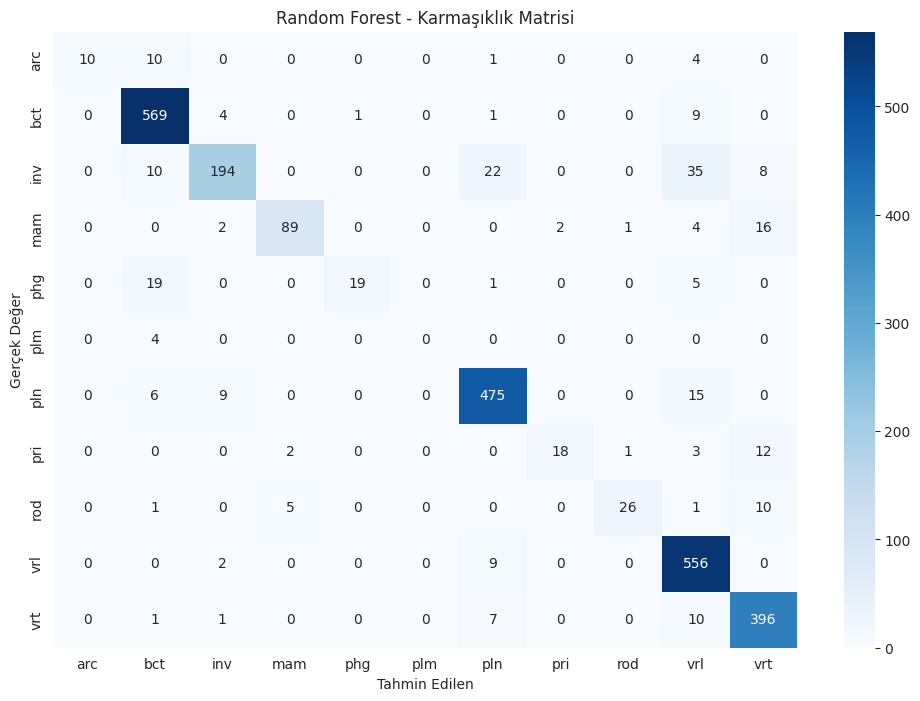

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Tahmin yapma
y_pred = best_rfc.predict(X_test_final)
y_prob = best_rfc.predict_proba(X_test_final)

# 2. Genel Performans Metrikleri
print("GENEL PERFORMANS METRİKLERİ")
print(f"Accuracy:  {accuracy_score(y_test_final, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_final, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test_final, y_pred, average='weighted'):.4f}")

# 3. Sınıf Bazlı Kırılım
print("\n SINIF BAZLI PERFORMANS (CLASS BASED)")
print(classification_report(y_test_final, y_pred, target_names=le.classes_))

# 4. karmaşıklık matrisi (confusion matrix) görselleştirme
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test_final, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

/tmp/ipython-input-3345758350.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


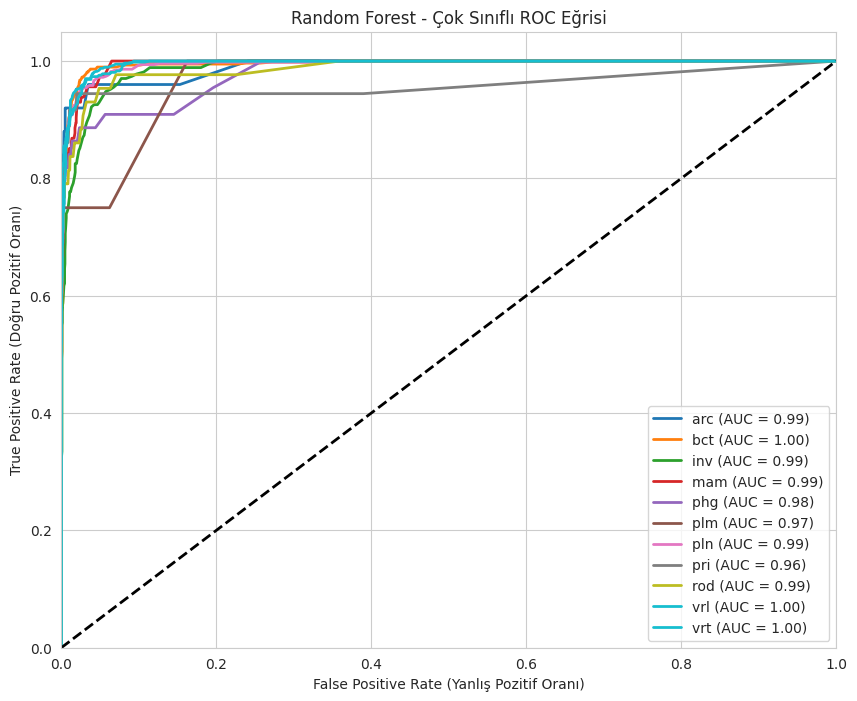

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Y etiketlerini binarize etme (ROC cıktısı icin yapılan adım)
y_test_bin = label_binarize(y_test_final, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Her sınıf için ROC hesaplama
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ROC Curve Çizimi
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Random Forest - Çok Sınıflı ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()